# Índice de Caminabilidad — Barrio Obrero
**ITT Cali Inteligente · Equipo de Gobierno de Datos**

Este notebook calcula las métricas de caminabilidad para el área del
**Barrio Obrero** (polígono único de barrio), usando la red peatonal de OpenStreetMap.

**Sistema de referencia:** WGS84 (EPSG:4326) para toda la información geoespacial.
Se usa EPSG:3116 (Colombia) únicamente para cálculos de área y distancia.

**Datos:** `data/Geojson_Barrio_Obrero/`

**Instrucciones:**
1. Ejecutar las celdas en orden
2. Los datos se cargan automáticamente
3. Los resultados y mapas se generan automáticamente

## Celda 1 — Instalación de dependencias

In [1]:
import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p in ['osmnx', 'geopandas', 'matplotlib', 'pandas', 'numpy', 'folium', 'seaborn', 'scipy']:
    check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


## Celda 2 — Importaciones y configuración

In [2]:
import os, re, json, warnings, datetime, logging
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import folium
warnings.filterwarnings('ignore')
logging.getLogger('pyogrio').setLevel(logging.ERROR)

# Sistema de referencia
CRS_WGS84 = 'EPSG:4326'      # Sistema de trabajo (geográfico)
CRS_COLOMBIA = 'EPSG:3116'    # Solo para cálculos de área/distancia (proyectado)

plt.rcParams.update({
    'figure.facecolor': '#F4F6F9',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
print(f'Sistema de referencia de trabajo: {CRS_WGS84}')
print(f'Sistema proyectado para cálculos: {CRS_COLOMBIA}')
print('Configuración lista')

Sistema de referencia de trabajo: EPSG:4326
Sistema proyectado para cálculos: EPSG:3116
Configuración lista


## Celda 3 — Parámetros, rutas y detección de entorno

In [3]:
# Repositorio del proyecto
REPO_URL = 'https://github.com/j0rg3c45/indice-caminabilidad-roosevelt.git'
REPO_NAME = 'indice-caminabilidad-roosevelt'

# Detectar entorno: Colab o local
if os.path.exists('/content'):
    import subprocess as _sp
    os.chdir('/content')
    _sp.getoutput(f'rm -rf {REPO_NAME}')
    print(_sp.getoutput(f'git clone {REPO_URL}'))
    PROJECT_ROOT = Path(f'/content/{REPO_NAME}')
else:
    PROJECT_ROOT = Path(os.getcwd()).parent

# Rutas relativas al proyecto
DATA_DIR = PROJECT_ROOT / 'data' / 'Geojson_Barrio_Obrero'
EVENTOS_DIR = DATA_DIR / 'nueva_data' / 'geojson_filtrado_poligono_Barrio_Obrero'
IMG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'

IMG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Búsqueda flexible de archivos GeoJSON
def find_file(base_dir, pattern):
    regex = re.compile(pattern, re.IGNORECASE)
    for root, _dirs, files in os.walk(base_dir):
        for f in files:
            if regex.search(f) and f.lower().endswith('.geojson'):
                return os.path.join(root, f)
    return None

# Rutas a los archivos de datos
PATHS = {
    'poligono':     find_file(DATA_DIR, r'Geojson_Barrio_Obrero\.geojson'),
    'comparendos':  find_file(EVENTOS_DIR, r'comparendos'),
    'homicidios':   find_file(EVENTOS_DIR, r'homicidios'),
    'hurtos':       find_file(EVENTOS_DIR, r'hurtos'),
    'vif':          find_file(EVENTOS_DIR, r'violencia_intrafamiliar'),
    'censo_arboreo': find_file(EVENTOS_DIR, r'CENSO_ARBOREO'),
}

ZONA_NOMBRE = 'Barrio Obrero — Cali'

print(f'DATA_DIR: {DATA_DIR}')
print(f'IMG_DIR:  {IMG_DIR}')
print(f'RESULTS_DIR: {RESULTS_DIR}')
print()
print('Archivos encontrados:')
for nombre, ruta in PATHS.items():
    ok = ruta is not None and os.path.exists(ruta)
    estado = chr(9989) if ok else chr(10060)
    print(f'  {estado}  {nombre:15s}: {Path(ruta).name if ruta else "NO ENCONTRADO"}')

DATA_DIR: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\data\Geojson_Barrio_Obrero
IMG_DIR:  C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures
RESULTS_DIR: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results

Archivos encontrados:
  ✅  poligono       : Geojson_Barrio_Obrero.geojson
  ✅  comparendos    : DATIC_comparendos_2023_2026T1_filtrado_poligono_Barrio_Obrero.geojson
  ✅  homicidios     : DATIC_homicidios_2023_2026T1_filtrado_poligono_Barrio_Obrero.geojson
  ✅  hurtos         : DATIC_hurtos_2023_2026T1_filtrado_poligono_Barrio_Obrero.geojson
  ✅  vif            : DATIC_violencia_intrafamiliar_2023_2026T1_filtrado_poligono_Barrio_Obrero.geojson
  ✅  censo_arboreo  : CENSO_ARBOREO_filtrado_poligono_Barrio_Obrero.geojson


## Celda 4 — Cargar polígono y asegurar WGS84

In [4]:
# Cargar polígono del barrio
gdf_poligono = gpd.read_file(PATHS['poligono'])

# Asegurar que el polígono esté en WGS84
if gdf_poligono.crs is None:
    print('AVISO: GeoJSON sin CRS definido, asignando WGS84')
    gdf_poligono = gdf_poligono.set_crs(CRS_WGS84)
elif gdf_poligono.crs.to_epsg() != 4326:
    print(f'Reproyectando polígono de {gdf_poligono.crs} a WGS84...')
    gdf_poligono = gdf_poligono.to_crs(CRS_WGS84)

# Polígono en WGS84 para OSMnx y visualización
polygon_wgs84 = gdf_poligono.geometry.iloc[0]

# Proyectar a EPSG:3116 SOLO para cálculos de área/distancia
gdf_proyectado = gdf_poligono.to_crs(CRS_COLOMBIA)
area_m2 = gdf_proyectado.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

print(f'\n=== ÁREA DE ESTUDIO ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  CRS de trabajo: {gdf_poligono.crs}')
print(f'  CRS para cálculos: {CRS_COLOMBIA}')
print(f'  Área: {area_m2:,.0f} m² ({area_m2/10000:.2f} ha)')
print(f'  Unidad de análisis: polígono único de barrio')

Reproyectando polígono de PROJCS["MAGNA-SIRGAS_CMT12",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4686"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","103599"]] a WGS84...

=== ÁREA DE ESTUDIO ===
  Zona: Barrio Obrero — Cali
  CRS de trabajo: EPSG:4326
  CRS para cálculos: EPSG:3116
  Área: 74,692 m² (7.47 ha)
  Unidad de análisis: polígono único de barrio


## Celda 5 — Descargar red peatonal desde OpenStreetMap

In [5]:
# OSMnx requiere el polígono en WGS84 (EPSG:4326)
print(f'Descargando red peatonal (polígono en {CRS_WGS84})...')
G = ox.graph_from_polygon(polygon_wgs84, network_type='walk', simplify=False)
print(f'Red descargada: {len(G.nodes)} nodos, {len(G.edges)} segmentos')
print(f'CRS del grafo: EPSG:4326 (WGS84)')

Descargando red peatonal (polígono en EPSG:4326)...


Red descargada: 26 nodos, 66 segmentos
CRS del grafo: EPSG:4326 (WGS84)


## Celda 6 — Calcular métricas de caminabilidad

In [6]:
# Calcular estadísticas (área en m² para densidades correctas)
stats = ox.basic_stats(G, area=area_m2)

# Exportar red peatonal como GeoJSON en la carpeta de datos de la zona de estudio
gdf_nodos, gdf_aristas = ox.graph_to_gdfs(G)
red_peatonal_path = DATA_DIR / 'red_peatonal_osm_barrio_obrero.geojson'
gdf_aristas.to_crs(CRS_WGS84).to_file(red_peatonal_path, driver='GeoJSON')
print(f'Red peatonal guardada en zona de estudio: {red_peatonal_path}')

longitud_total_km = stats['edge_length_total'] / 1000
densidad_km_km2 = longitud_total_km / area_km2

metricas_caminabilidad = {
    'Intersecciones peatonales': stats['intersection_count'],
    'Longitud red peatonal (km)': round(longitud_total_km, 2),
    'Longitud promedio segmento (m)': round(stats['edge_length_avg'], 1),
    'Densidad calle (km/km²)': round(densidad_km_km2, 2),
    'Nodos OSM': len(G.nodes),
    'Segmentos OSM': len(G.edges),
}

print('=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS análisis: {CRS_WGS84} | Cálculos métricos: {CRS_COLOMBIA}')
print()
for k, v in metricas_caminabilidad.items():
    print(f'  {k}: {v}')

Red peatonal guardada en zona de estudio: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\data\Geojson_Barrio_Obrero\red_peatonal_osm_barrio_obrero.geojson
=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===
  Fecha: 2026-09-18
  CRS análisis: EPSG:4326 | Cálculos métricos: EPSG:3116

  Intersecciones peatonales: 26
  Longitud red peatonal (km): 3.6
  Longitud promedio segmento (m): 54.6
  Densidad calle (km/km²): 48.26
  Nodos OSM: 26
  Segmentos OSM: 66


## Celda 7 — Cargar datos geoespaciales complementarios (WGS84)

In [7]:
# Cargar todos los datasets y asegurar WGS84
datasets = {}
print('=== CARGA DE DATASETS (normalizados a WGS84) ===')
print()
for nombre, ruta in PATHS.items():
    if ruta and os.path.exists(ruta) and nombre != 'poligono':
        try:
            gdf = gpd.read_file(ruta)
            # Asegurar WGS84
            if gdf.crs is None:
                gdf = gdf.set_crs(CRS_WGS84)
            elif gdf.crs.to_epsg() != 4326:
                gdf = gdf.to_crs(CRS_WGS84)
            datasets[nombre] = gdf
            print(f'  {chr(9989)} {nombre:15s}: {len(gdf):>5} registros | CRS: {gdf.crs.to_epsg()}')
        except Exception as e:
            print(f'  {chr(10060)} {nombre:15s}: Error - {e}')

print(f'\nTotal datasets cargados: {len(datasets)}')
print(f'Todos en CRS: {CRS_WGS84}')

=== CARGA DE DATASETS (normalizados a WGS84) ===



  ✅ comparendos    :  3741 registros | CRS: 4326
  ✅ homicidios     :    27 registros | CRS: 4326
  ✅ hurtos         :   663 registros | CRS: 4326
  ✅ vif            :    82 registros | CRS: 4326
  ✅ censo_arboreo  :   874 registros | CRS: 4326

Total datasets cargados: 5
Todos en CRS: EPSG:4326


## Celda 8 — Mapa estático de la red peatonal

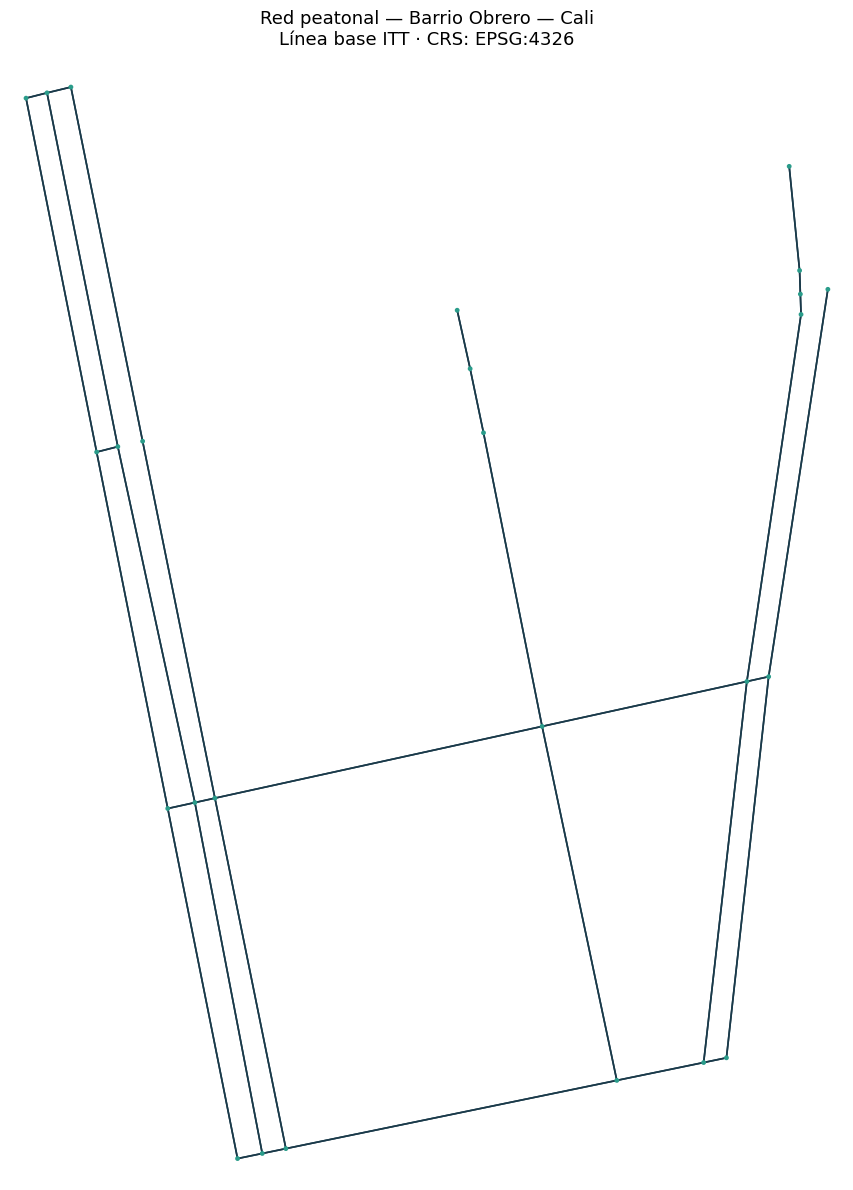

Mapa guardado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\barrio_obrero_red_peatonal_linea_base.png


In [8]:
fig, ax = ox.plot_graph(
    G,
    node_size=12,
    edge_linewidth=1.2,
    bgcolor='white',
    node_color='#2A9C8A',
    edge_color='#1A3A4A',
    figsize=(12, 12),
    show=False,
    close=False
)
ax.set_title(
    f'Red peatonal — {ZONA_NOMBRE}\nLínea base ITT · CRS: {CRS_WGS84}',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'barrio_obrero_red_peatonal_linea_base.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa guardado: {IMG_DIR / "barrio_obrero_red_peatonal_linea_base.png"}')

## Celda 9 — Mapa interactivo con capas (WGS84)

In [9]:
# Mapa interactivo — todo en WGS84
centroid = polygon_wgs84.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16, tiles=None)

# Capas base
folium.TileLayer('CartoDB positron', name='CartoDB Claro').add_to(m)
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Esri Satélite', overlay=False
).add_to(m)

# Google tiles
google_streets = 'http://{s}.google.com/vt/lyrs=m&x={x}&y={y}&z={z}'
google_satellite = 'http://{s}.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
folium.TileLayer(
    tiles=google_streets,
    attr='Google', name='Google Streets',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)
folium.TileLayer(
    tiles=google_satellite,
    attr='Google', name='Google Satélite',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)

# Polígono del barrio (ya en WGS84)
folium.GeoJson(
    gdf_poligono.__geo_interface__,
    name='Polígono Barrio Obrero',
    style_function=lambda x: {'color': '#1B4F8A', 'fillColor': '#2E7D32',
                              'fillOpacity': 0.1, 'weight': 2}
).add_to(m)

# Red peatonal OSM (descargada en Celda 5)
gdf_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
gdf_edges_wgs84 = gdf_edges.to_crs(CRS_WGS84) if gdf_edges.crs.to_epsg() != 4326 else gdf_edges
folium.GeoJson(
    gdf_edges_wgs84[['geometry']].__geo_interface__,
    name='Red peatonal OSM (líneas)',
    style_function=lambda x: {'color': '#2A9C8A', 'weight': 2, 'opacity': 0.7}
).add_to(m)

# Nodos del grafo (intersecciones)
gdf_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_wgs84 = gdf_nodes.to_crs(CRS_WGS84) if gdf_nodes.crs.to_epsg() != 4326 else gdf_nodes
fg_nodos = folium.FeatureGroup(name='Nodos (intersecciones)', show=True)
for _, row in gdf_nodes_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3, color='#E53935', fill=True, fill_opacity=0.9, weight=1
    ).add_to(fg_nodos)
fg_nodos.add_to(m)

# Colores por capa
COLORES = {
    'comparendos': 'orange', 'homicidios': 'darkred',
    'hurtos': 'purple', 'vif': 'darkpurple', 'censo_arboreo': 'green',
}

# Agregar capas de eventos (todas en WGS84)
for nombre, gdf in datasets.items():
    fg = folium.FeatureGroup(name=nombre.replace('_', ' ').capitalize(), show=False)
    color = COLORES.get(nombre, 'gray')
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        if geom.geom_type == 'Point':
            folium.CircleMarker(
                location=[geom.y, geom.x],
                radius=3, color=color, fill=True, fill_opacity=0.6
            ).add_to(fg)
    fg.add_to(m)

folium.LayerControl().add_to(m)
print(f'Mapa interactivo generado — CRS: {CRS_WGS84}')
m

Mapa interactivo generado — CRS: EPSG:4326


## Celda 10 — Indicadores complementarios

In [10]:
print('=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS: {CRS_WGS84} (cálculos de densidad con área en {CRS_COLOMBIA})')
print()

indicadores = {}
for nombre, gdf in datasets.items():
    n_registros = len(gdf)
    densidad = n_registros / (area_m2 / 10000)  # por hectárea
    indicadores[nombre] = {'total': n_registros, 'densidad_por_ha': round(densidad, 2)}
    print(f'  {nombre:15s}: {n_registros:>5} registros | {densidad:.2f} por ha')

print()
print('Nota: estos valores constituyen la línea base pre-intervención.')

=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===
  Zona: Barrio Obrero — Cali
  Fecha: 2026-09-18
  CRS: EPSG:4326 (cálculos de densidad con área en EPSG:3116)

  comparendos    :  3741 registros | 500.85 por ha
  homicidios     :    27 registros | 3.61 por ha
  hurtos         :   663 registros | 88.76 por ha
  vif            :    82 registros | 10.98 por ha
  censo_arboreo  :   874 registros | 117.01 por ha

Nota: estos valores constituyen la línea base pre-intervención.


## Celda 10B — Gráfico de indicadores complementarios

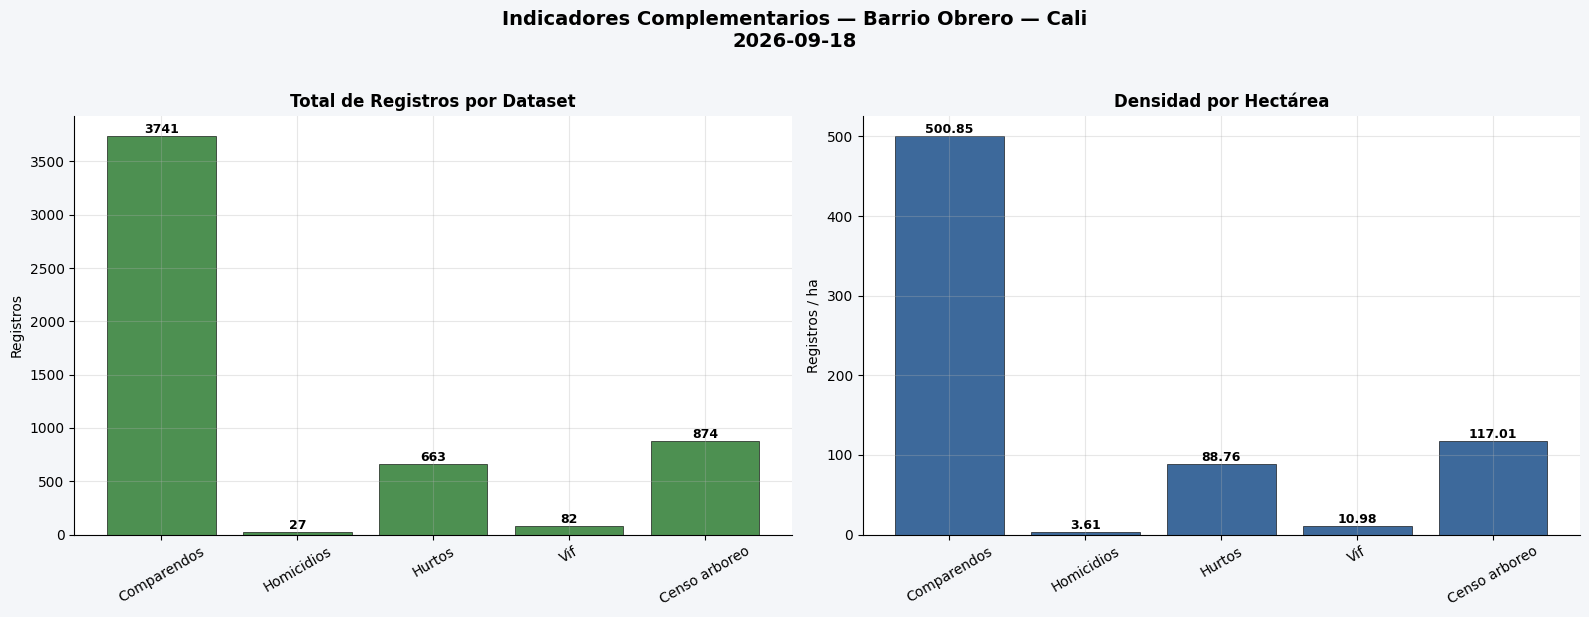

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\barrio_obrero_indicadores_complementarios.png


In [11]:
# Gráfico de barras de indicadores complementarios
if indicadores:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    nombres = list(indicadores.keys())
    totales = [indicadores[n]['total'] for n in nombres]
    densidades = [indicadores[n]['densidad_por_ha'] for n in nombres]
    labels = [n.replace('_', ' ').capitalize() for n in nombres]

    bars0 = axes[0].bar(labels, totales, color='#2E7D32', alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[0].set_title('Total de Registros por Dataset', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Registros')
    axes[0].tick_params(axis='x', rotation=30)
    for b, v in zip(bars0, totales):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height(), f'{v}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    bars1 = axes[1].bar(labels, densidades, color='#1B4F8A', alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Densidad por Hectárea', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Registros / ha')
    axes[1].tick_params(axis='x', rotation=30)
    for b, v in zip(bars1, densidades):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle(f'Indicadores Complementarios — {ZONA_NOMBRE}\n{datetime.date.today().isoformat()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'barrio_obrero_indicadores_complementarios.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Exportado: {IMG_DIR / "barrio_obrero_indicadores_complementarios.png"}')
else:
    print('⚠ No hay indicadores para graficar')

## Celda 11 — Exportar resultados

In [12]:
resultado = {
    'fecha_medicion': datetime.date.today().isoformat(),
    'poligono': 'Barrio Obrero',
    'crs_trabajo': CRS_WGS84,
    'crs_calculo': CRS_COLOMBIA,
    'area_m2': round(area_m2, 0),
    'area_ha': round(area_m2 / 10000, 2),
    'intersecciones_peatonales': stats['intersection_count'],
    'longitud_red_peatonal_km': round(longitud_total_km, 2),
    'longitud_promedio_segmento_m': round(stats['edge_length_avg'], 1),
    'densidad_calle_km_km2': round(densidad_km_km2, 2),
    'nodos_osm': len(G.nodes),
    'segmentos_osm': len(G.edges),
    'fuente': 'OpenStreetMap via OSMnx',
    'momento': 'linea_base_pre_intervencion',
}

# Agregar conteos complementarios
for nombre, vals in indicadores.items():
    resultado[f'total_{nombre}'] = vals['total']
    resultado[f'densidad_{nombre}_por_ha'] = vals['densidad_por_ha']

df_resultados = pd.DataFrame([resultado])
output_csv = RESULTS_DIR / 'barrio_obrero_caminabilidad_linea_base.csv'
df_resultados.to_csv(output_csv, index=False)
print(f'Resultados exportados: {output_csv}')
print()
print(df_resultados.T.to_string())

Resultados exportados: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results\barrio_obrero_caminabilidad_linea_base.csv

                                                         0
fecha_medicion                                  2026-09-18
poligono                                     Barrio Obrero
crs_trabajo                                      EPSG:4326
crs_calculo                                      EPSG:3116
area_m2                                            74692.0
area_ha                                               7.47
intersecciones_peatonales                               26
longitud_red_peatonal_km                               3.6
longitud_promedio_segmento_m                          54.6
densidad_calle_km_km2                                48.26
nodos_osm                                               26
segmentos_osm                                           66
fuente                             OpenStreetMap via OSMnx
momento                    

---
# GRÁFICOS BASE — Línea Base de Caminabilidad

Los siguientes gráficos constituyen la caracterización espacial y topológica
del Barrio Obrero para evaluación de impacto de la intervención.

## Gráfico 1 — Mapa de red peatonal (alta resolución)

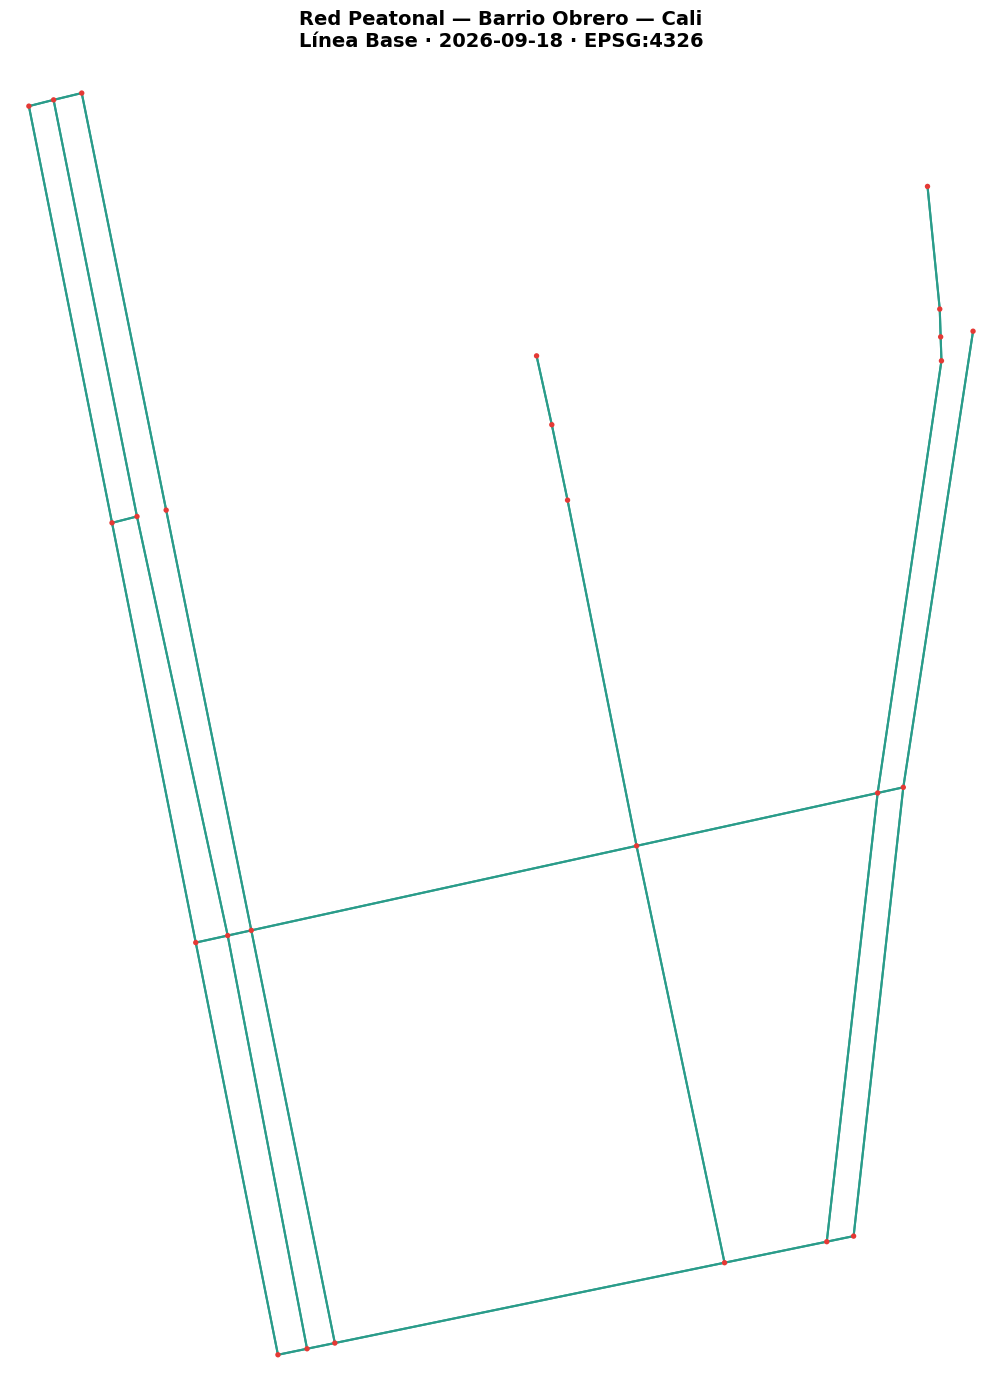

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_01_red_peatonal_barrio_obrero.png


In [13]:
fig, ax = ox.plot_graph(
    G,
    node_size=15,
    node_color='#E53935',
    edge_linewidth=1.5,
    edge_color='#2A9C8A',
    bgcolor='white',
    figsize=(14, 14),
    show=False,
    close=False
)
ax.set_title(
    f'Red Peatonal — {ZONA_NOMBRE}\nLínea Base · {datetime.date.today().isoformat()} · {CRS_WGS84}',
    fontsize=14, pad=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_01_red_peatonal_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_01_red_peatonal_barrio_obrero.png"}')

## Gráfico 2 — Heatmap de densidad de intersecciones

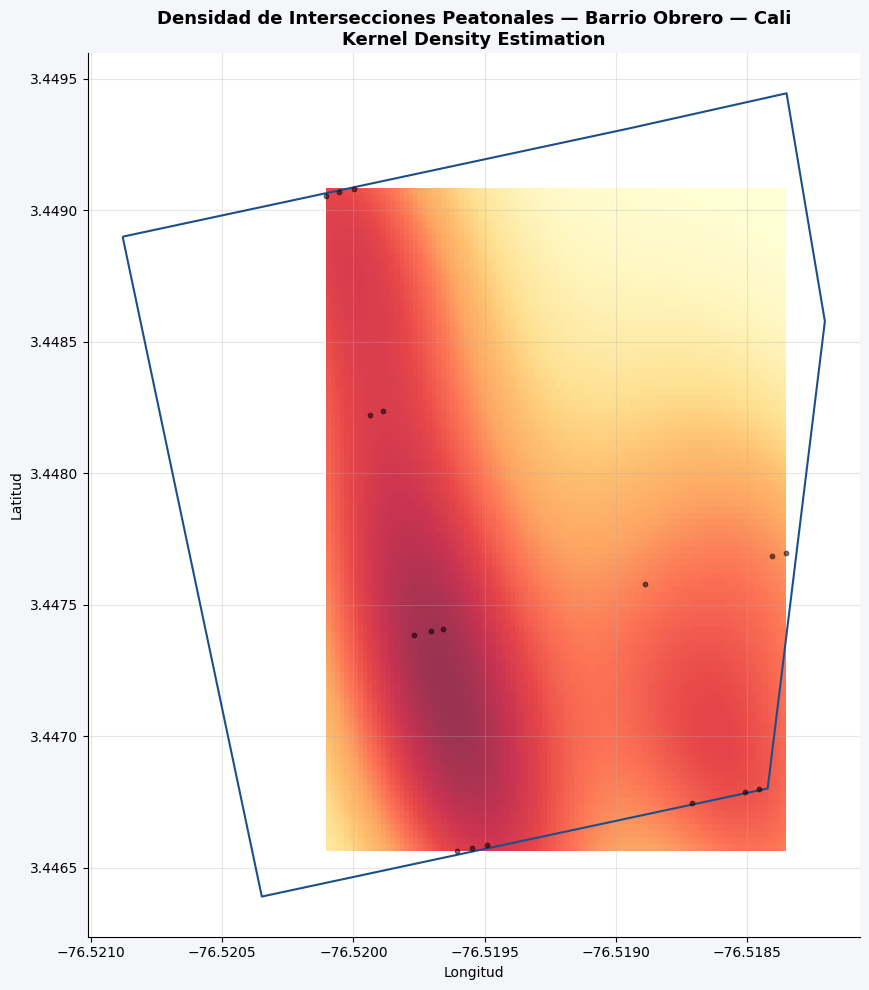

Intersecciones analizadas: 17
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_02_heatmap_intersecciones_barrio_obrero.png


In [14]:
from scipy.stats import gaussian_kde
# Obtener nodos que son intersecciones
gdf_nodes_all = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_all = gdf_nodes_all.to_crs(CRS_WGS84)

if 'street_count' in gdf_nodes_all.columns:
    intersecciones = gdf_nodes_all[gdf_nodes_all['street_count'] > 2]
else:
    intersecciones = gdf_nodes_all

x = intersecciones.geometry.x.values
y = intersecciones.geometry.y.values

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
if len(x) > 5:
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    density = kde(positions).reshape(xx.shape)
    ax.imshow(np.rot90(density), extent=[xmin, xmax, ymin, ymax],
              cmap='YlOrRd', aspect='auto', alpha=0.8)
    ax.scatter(x, y, s=10, c='black', alpha=0.5, zorder=5)
else:
    ax.scatter(x, y, s=30, c='red')

gdf_poligono.boundary.plot(ax=ax, color='#1B4F8A', linewidth=1.5)
ax.set_title(f'Densidad de Intersecciones Peatonales — {ZONA_NOMBRE}\nKernel Density Estimation',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_02_heatmap_intersecciones_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Intersecciones analizadas: {len(intersecciones)}')
print(f'Exportado: {IMG_DIR / "graf_02_heatmap_intersecciones_barrio_obrero.png"}')

## Gráfico 3 — Histograma de longitud de segmentos

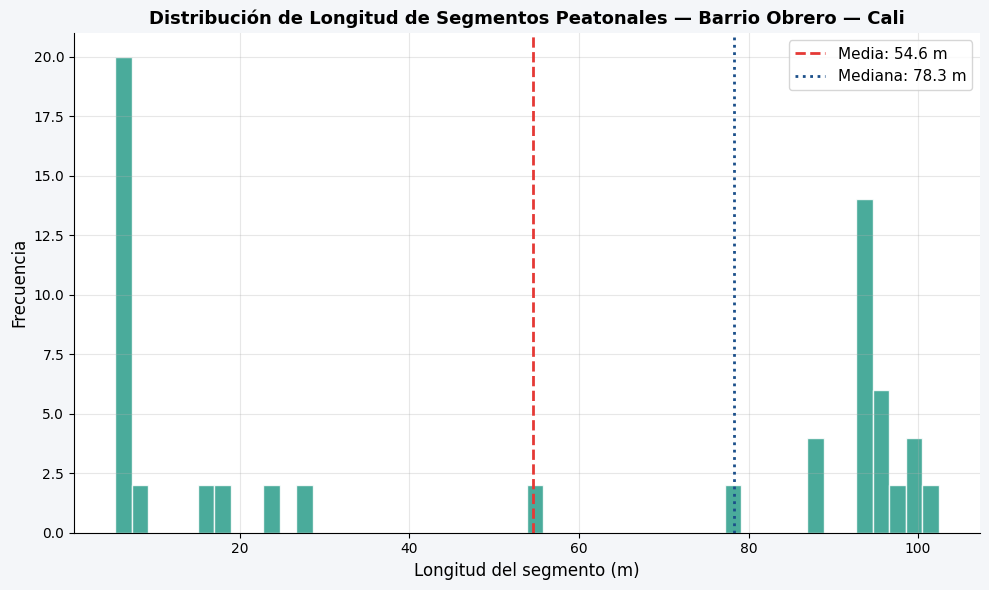

Segmentos: 66 | Media: 54.6m | Mediana: 78.3m
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_03_histograma_segmentos_barrio_obrero.png


In [15]:
gdf_edges_all = ox.graph_to_gdfs(G, nodes=False, edges=True)
longitudes = gdf_edges_all['length'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(longitudes, bins=50, color='#2A9C8A', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(longitudes), color='#E53935', linestyle='--', linewidth=2,
           label=f'Media: {np.mean(longitudes):.1f} m')
ax.axvline(np.median(longitudes), color='#1B4F8A', linestyle=':', linewidth=2,
           label=f'Mediana: {np.median(longitudes):.1f} m')
ax.set_xlabel('Longitud del segmento (m)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Distribución de Longitud de Segmentos Peatonales — {ZONA_NOMBRE}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_03_histograma_segmentos_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Segmentos: {len(longitudes)} | Media: {np.mean(longitudes):.1f}m | Mediana: {np.median(longitudes):.1f}m')
print(f'Exportado: {IMG_DIR / "graf_03_histograma_segmentos_barrio_obrero.png"}')

## Gráfico 4 — Boxplot de segmentos peatonales

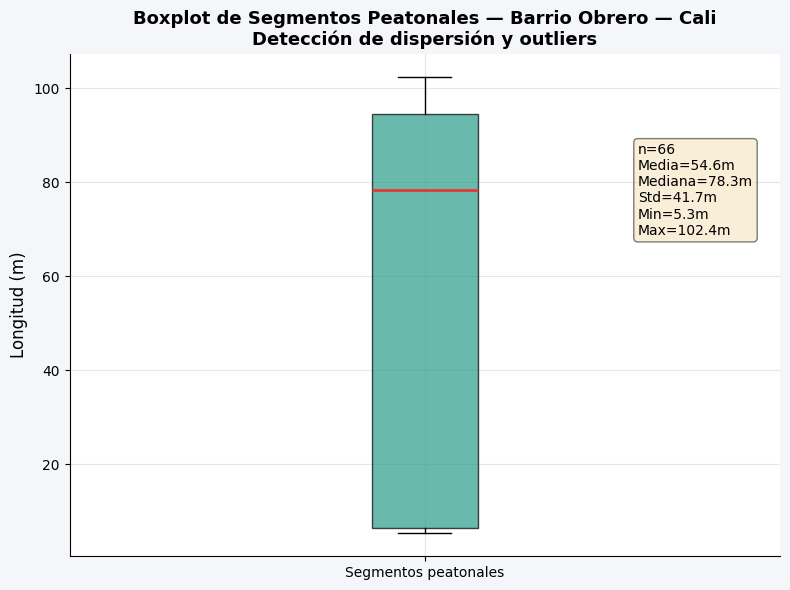

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_04_boxplot_segmentos_barrio_obrero.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(longitudes, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2A9C8A', alpha=0.7),
                medianprops=dict(color='#E53935', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#1B4F8A', markersize=4, alpha=0.5))
ax.set_ylabel('Longitud (m)', fontsize=12)
ax.set_title(f'Boxplot de Segmentos Peatonales — {ZONA_NOMBRE}\nDetección de dispersión y outliers',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(['Segmentos peatonales'])
stats_text = (f'n={len(longitudes)}\n'
              f'Media={np.mean(longitudes):.1f}m\n'
              f'Mediana={np.median(longitudes):.1f}m\n'
              f'Std={np.std(longitudes):.1f}m\n'
              f'Min={np.min(longitudes):.1f}m\n'
              f'Max={np.max(longitudes):.1f}m')
ax.text(1.3, np.median(longitudes), stats_text, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_04_boxplot_segmentos_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_04_boxplot_segmentos_barrio_obrero.png"}')

## Gráfico 5 — Posición morfológica (conectividad)

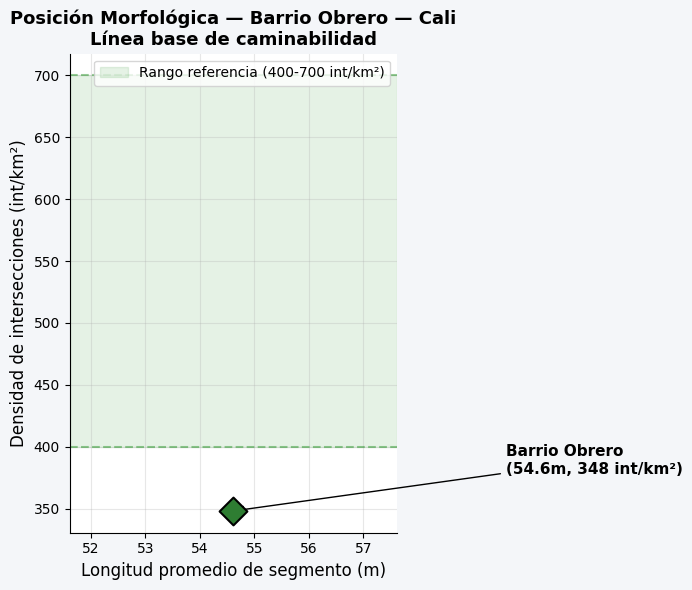

Longitud promedio: 54.6 m
Densidad intersecciones: 348 int/km²
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_05_scatter_conectividad_barrio_obrero.png


In [17]:
long_prom = np.mean(longitudes)
densidad_intersecciones = stats['intersection_count'] / area_km2

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(long_prom, densidad_intersecciones, s=200, c='#2E7D32', marker='D',
           edgecolors='black', linewidth=1.5, zorder=5)
ax.annotate(f'Barrio Obrero\n({long_prom:.1f}m, {densidad_intersecciones:.0f} int/km²)',
            xy=(long_prom, densidad_intersecciones),
            xytext=(long_prom + 5, densidad_intersecciones + 30),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.axhspan(400, 700, alpha=0.1, color='green', label='Rango referencia (400-700 int/km²)')
ax.axhline(400, color='green', linestyle='--', alpha=0.4)
ax.axhline(700, color='green', linestyle='--', alpha=0.4)
ax.set_xlabel('Longitud promedio de segmento (m)', fontsize=12)
ax.set_ylabel('Densidad de intersecciones (int/km²)', fontsize=12)
ax.set_title(f'Posición Morfológica — {ZONA_NOMBRE}\nLínea base de caminabilidad',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_05_scatter_conectividad_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Longitud promedio: {long_prom:.1f} m')
print(f'Densidad intersecciones: {densidad_intersecciones:.0f} int/km²')
print(f'Exportado: {IMG_DIR / "graf_05_scatter_conectividad_barrio_obrero.png"}')

## Gráfico 6 — Tabla resumen de métricas urbanas

=== TABLA RESUMEN — Barrio Obrero — Cali ===
Fecha: 2026-09-18 | CRS: EPSG:4326

                             Métrica    Valor
                     Área total (ha)   7.4700
                    Área total (km²)   0.0747
           Intersecciones peatonales  26.0000
          Longitud total de red (km)   3.6000
      Longitud promedio segmento (m)  54.6000
                Mediana segmento (m)  78.3000
          Densidad de calle (km/km²)  48.2600
Densidad de intersecciones (int/km²) 348.0000
                           Nodos OSM  26.0000
                       Segmentos OSM  66.0000

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results\barrio_obrero_tabla_resumen_metricas.csv


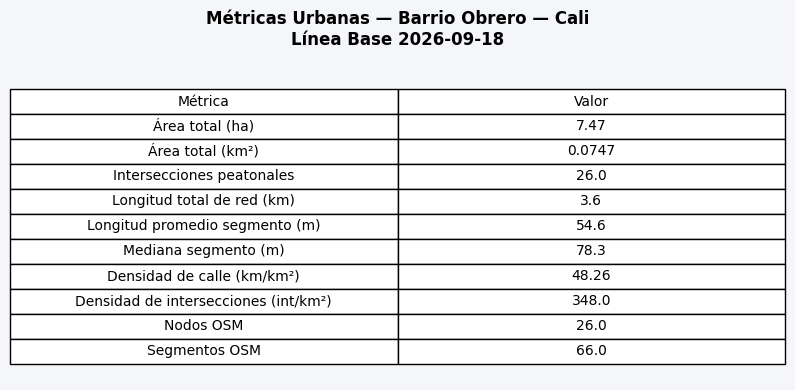

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_06_tabla_metricas_barrio_obrero.png


In [18]:
densidad_intersecciones_km2 = stats['intersection_count'] / area_km2
tabla_resumen = pd.DataFrame({
    'Métrica': [
        'Área total (ha)',
        'Área total (km²)',
        'Intersecciones peatonales',
        'Longitud total de red (km)',
        'Longitud promedio segmento (m)',
        'Mediana segmento (m)',
        'Densidad de calle (km/km²)',
        'Densidad de intersecciones (int/km²)',
        'Nodos OSM',
        'Segmentos OSM',
    ],
    'Valor': [
        round(area_m2 / 10000, 2),
        round(area_km2, 4),
        stats['intersection_count'],
        round(longitud_total_km, 2),
        round(np.mean(longitudes), 1),
        round(np.median(longitudes), 1),
        round(densidad_km_km2, 2),
        round(densidad_intersecciones_km2, 0),
        len(G.nodes),
        len(G.edges),
    ]
})

print(f'=== TABLA RESUMEN — {ZONA_NOMBRE} ===')
print(f'Fecha: {datetime.date.today().isoformat()} | CRS: {CRS_WGS84}')
print()
print(tabla_resumen.to_string(index=False))

tabla_resumen.to_csv(RESULTS_DIR / 'barrio_obrero_tabla_resumen_metricas.csv', index=False)
print(f'\nExportado: {RESULTS_DIR / "barrio_obrero_tabla_resumen_metricas.csv"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(cellText=tabla_resumen.values, colLabels=tabla_resumen.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title(f'Métricas Urbanas — {ZONA_NOMBRE}\nLínea Base {datetime.date.today().isoformat()}',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_06_tabla_metricas_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_06_tabla_metricas_barrio_obrero.png"}')